# HW 2

In [48]:
# Part 2

import cv2 as cv
import numpy as np
from pathlib import Path

#BGR
img = cv.imread("./Part2_Pictures/HW1_IMG_CS898BA.png")

b = img[:, :, 0]
g = img[:, :, 1]
r = img[:, :, 2]

b = cv.equalizeHist(b)
g = cv.equalizeHist(g)
r = cv.equalizeHist(r)
normalized_img = cv.merge([b, g, r])

cv.imwrite("./Hw2_Pictures/normalized.png", normalized_img)

True

In [49]:
import matplotlib.pyplot as plt

def show_image(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

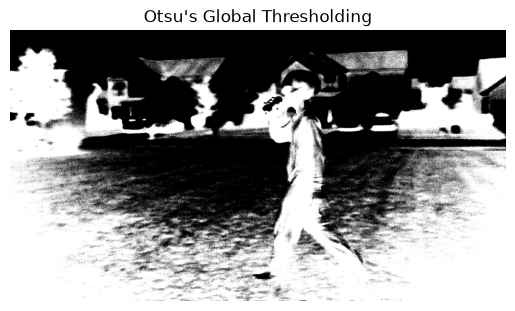

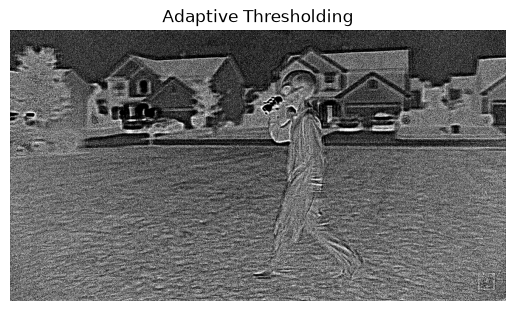

True

In [50]:
# Part 3

grayscale = cv.cvtColor(normalized_img, cv.COLOR_BGR2GRAY)

ret, otsu = cv.threshold(grayscale, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
show_image(otsu, "Otsu's Global Thresholding")

gauss = cv.adaptiveThreshold(grayscale, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, 31, 5)
show_image(gauss, "Adaptive Thresholding")

cv.imwrite("./Hw2_Pictures/OtsuGlobalThresholding.png", otsu)
cv.imwrite("./Hw2_Pictures/AdaptiveThresholding.png", gauss)

otsu_fg = cv.bitwise_and(normalized_img, normalized_img, mask=otsu)
gauss_fg = cv.bitwise_and(normalized_img, normalized_img, mask=gauss)
cv.imwrite("./Hw2_Pictures/OtsuForeground.png", otsu_fg)
cv.imwrite("./Hw2_Pictures/AdaptiveForeground.png", gauss_fg)

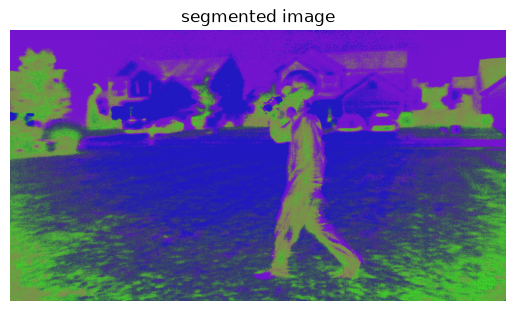

In [ ]:
# Part 4

hsv_normalized = cv.cvtColor(normalized_img, cv.COLOR_BGR2HSV)

pixel_vals = hsv_normalized.reshape((-1,3))
pixel_vals = np.float32(pixel_vals)

# 100 iterations, 85% acc
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.85)
k = 5
retval, labels, centers = cv.kmeans(pixel_vals, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]

segmented_image = segmented_data.reshape((hsv_normalized.shape))

show_image(segmented_image, "segmented image")

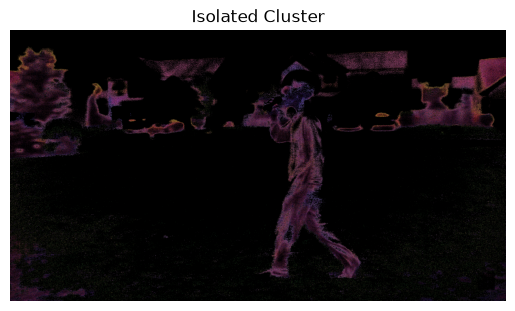

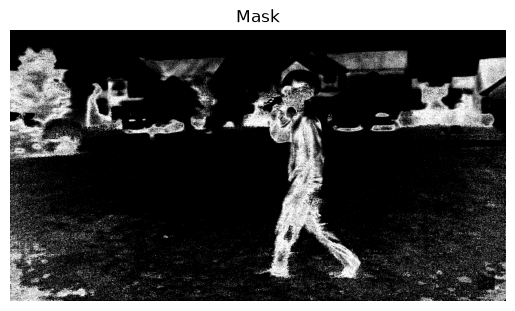

True

In [55]:
cluster_num = 4

mask = np.uint8(labels.flatten() == cluster_num) * 255
mask = mask.reshape(hsv_normalized.shape[:2])

foreground = cv.bitwise_and(normalized_img, normalized_img, mask=mask)

show_image(foreground, "Isolated Cluster")
show_image(mask, "Mask")

cv.imwrite("./Hw2_Pictures/Kmeans_foreground.png", foreground)
cv.imwrite("./Hw2_Pictures/Kmeans_mask.png", mask)

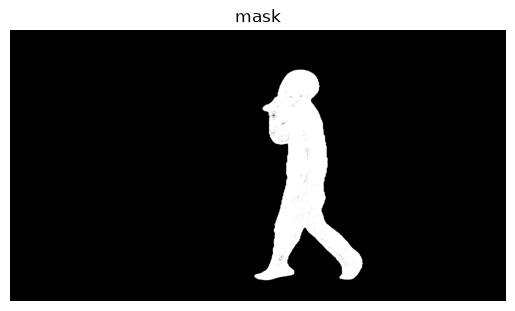

True

In [56]:
# Part 5

mask_gt = cv.imread("./Hw2_Pictures/MASK.png")
mask_gt = cv.cvtColor(mask_gt, cv.COLOR_BGR2GRAY)
_, mask_gt = cv.threshold(mask_gt, 0, 255, cv.THRESH_BINARY)
show_image(mask_gt, "mask")
cv.imwrite("./Hw2_Pictures/ground_truth.png", mask_gt)

In [57]:
# Part 5.2 

def metrics(mask, gt):
    mask = mask.astype(bool)
    gt = gt.astype(bool)
    intersect = np.logical_and(mask, gt)
    union = np.logical_or(mask, gt)
    mag_int = intersect.sum()
    mag_union = union.sum()
    iou = mag_int / mag_union
    
    # dice 
    dice = (2 * mag_int) / (mask.sum() + gt.sum())
    return iou, dice

masks = [otsu, gauss, mask]

iou, dice = metrics(masks[0], mask_gt)
print(f"Otsu: IoU = {iou:.4f}, Dice = {dice:.4f}")

iou, dice = metrics(masks[1], mask_gt)
print(f"gauss: IoU = {iou:.4f}, Dice = {dice:.4f}")

iou, dice = metrics(masks[2], mask_gt)
print(f"K-Means: IoU = {iou:.4f}, Dice = {dice:.4f}")

Otsu: IoU = 0.0993, Dice = 0.1807
gauss: IoU = 0.0704, Dice = 0.1316
K-Means: IoU = 0.2089, Dice = 0.3456


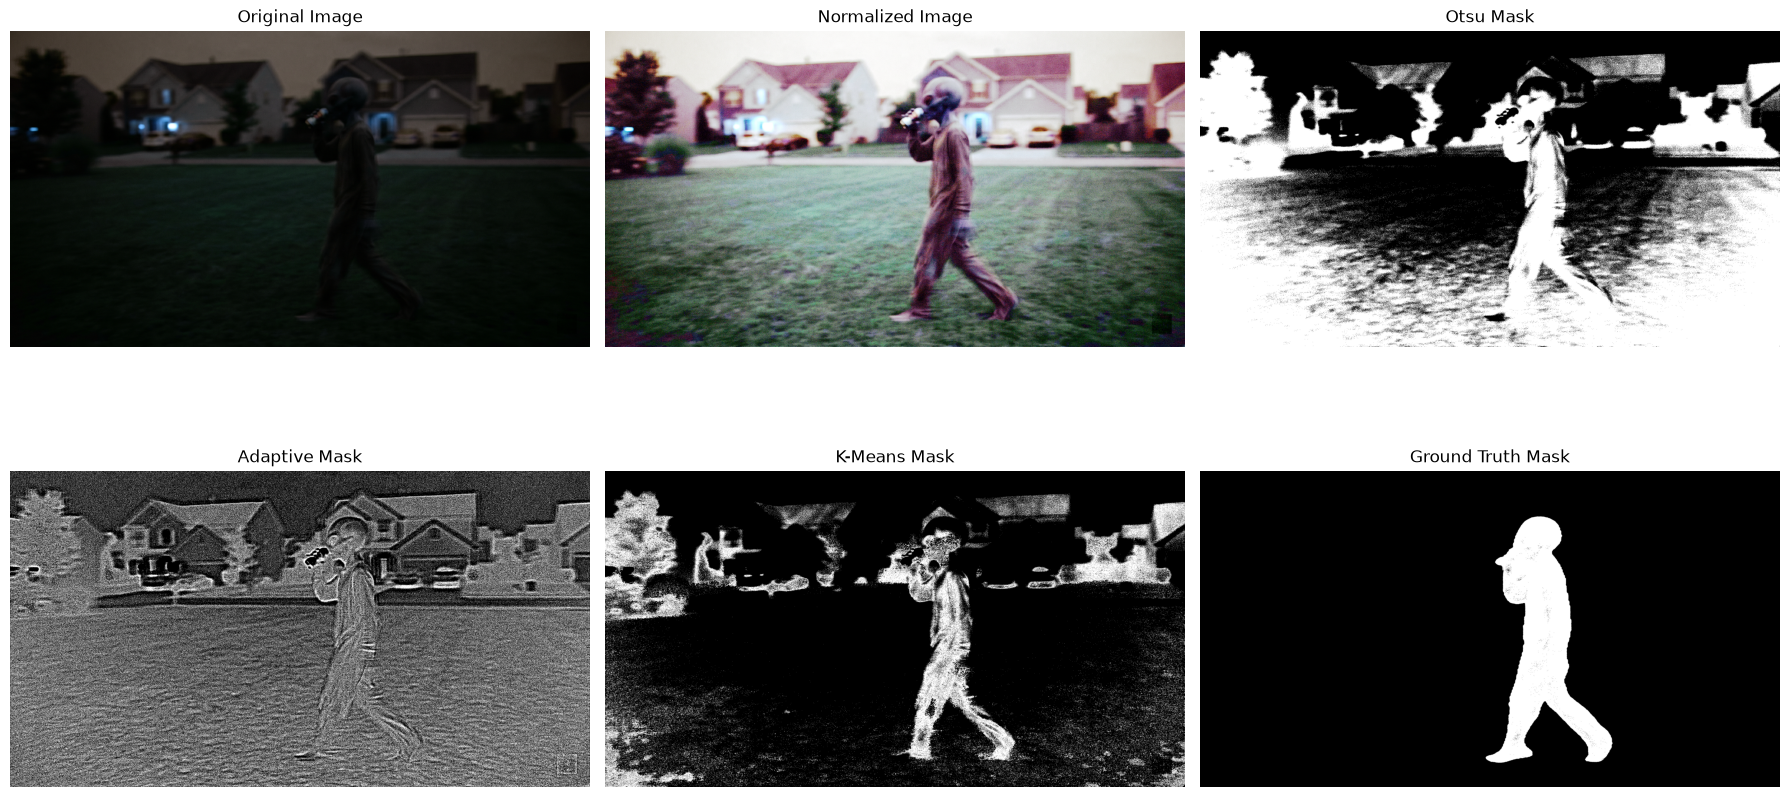

In [5]:
# PLot
import cv2 as cv
import matplotlib.pyplot as plt

original = cv.imread("./Part2_Pictures/HW1_IMG_CS898BA.png", cv.COLOR_BGR2RGB)
normalized = cv.imread("./Hw2_Pictures/normalized.png", cv.COLOR_BGR2RGB)
otsu = cv.imread("./Hw2_Pictures/OtsuGlobalThresholding.png", cv.COLOR_BGR2RGB)
gauss = cv.imread("./Hw2_Pictures/AdaptiveThresholding.png", cv.COLOR_BGR2RGB)
kmeans = cv.imread("./Hw2_Pictures/Kmeans_mask.png", cv.COLOR_BGR2RGB)
mask = cv.imread("./Hw2_Pictures/ground_truth.png")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(original)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(normalized)
axes[0, 1].set_title("Normalized Image")
axes[0, 1].axis('off')

axes[0, 2].imshow(otsu, cmap='gray')
axes[0, 2].set_title("Otsu Mask")
axes[0, 2].axis('off')

axes[1, 0].imshow(gauss, cmap='gray')
axes[1, 0].set_title("Adaptive Mask")
axes[1, 0].axis('off')

axes[1, 1].imshow(kmeans, cmap='gray')
axes[1, 1].set_title("K-Means Mask")
axes[1, 1].axis('off')

axes[1, 2].imshow(mask)
axes[1, 2].set_title("Ground Truth Mask")
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig("./Hw2_Pictures/comparison_plot.png", dpi=150, bbox_inches='tight')
plt.show()